<a href="https://colab.research.google.com/github/aorilla553533/CST9_Final_Project/blob/main/Final_na_Final_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
# NOTE: Update the path to match your local or Colab environment
file_path = 'unified_scam_detection_dataset.csv'  # e.g., '/content/unified_scam_detection_dataset.csv' on Colab
df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)
print('\nColumn names:\n', df.columns.tolist())
print('\nFirst 5 rows:\n', df.head())
print('\nData types:\n', df.dtypes)
print('\nBasic info:\n')
df.info()

In [28]:
# ==============================================================================
# Cell 1: Environment Setup & Package Initialization
# ==============================================================================
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Core Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob
from scipy.sparse import hstack

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve
)

# Download required NLTK corpora
print("📥 Downloading NLTK corpora...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ Setup complete! Libraries imported successfully.")

📥 Downloading NLTK corpora...
✅ Setup complete! Libraries imported successfully.


In [29]:
# ==============================================================================
# Cell 2: Dataset Loading
# ==============================================================================
# Check if file exists; if running in Google Colab without the file, prompt upload.
DATASET_FILENAME = 'unified_scam_detection_dataset.csv'

if not os.path.exists(DATASET_FILENAME):
    print(f"⚠️ '{DATASET_FILENAME}' not found in the local runtime.")
    from google.colab import files
    print("📤 Please upload your dataset CSV:")
    uploaded = files.upload()
    DATASET_FILENAME = list(uploaded.keys())[0]

df = pd.read_csv(DATASET_FILENAME)

print("=" * 60)
print(f"📊 DATASET LOADED: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target Distribution (user_success):\n{df['user_success'].value_counts(normalize=True).round(4) * 100}%")
print("=" * 60)
df.head(3)

⚠️ 'unified_scam_detection_dataset.csv' not found in the local runtime.
📤 Please upload your dataset CSV:


Saving unified_scam_detection_dataset.csv to unified_scam_detection_dataset.csv
📊 DATASET LOADED: 1000 rows, 23 columns
Target Distribution (user_success):
user_success
1    85.5
0    14.5
Name: proportion, dtype: float64%


,conversation_id,scammer_message,user_response,response_type,scam_tactic,risk_score,risk_level,effectiveness_score,timestamp,urgency_keywords,...,authority_claims,threat_indicators,total_scam_indicators,contains_verification,contains_refusal,contains_expertise,response_strength,is_scam,scam_category,user_success
0,SCAM_0001,This is a mandatory security procedure,I'll check with the bank first,expert_mention,emotional_manipulation,4,medium,5,6/14/2025 5:08,0,...,2,0,2,1,0,0,5,1,emotional_manipulation,1
1,SCAM_0002,Account activation charge,I work in cybersecurity and I know these tactics,expert_mention,threat,9,critical,4,9/21/2025 17:00,0,...,0,0,1,0,1,1,4,1,threat,1
2,SCAM_0003,I will lose my job if you don't pay,I'll wait for technical support response,questioning,isolation,10,critical,3,12/11/2024 9:50,0,...,0,1,2,0,0,0,3,1,isolation,0


In [30]:
# ==============================================================================
# Cell 3: NLP Preprocessing & Stylometric Feature Extractor
# ==============================================================================
class AdvancedTextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def clean_text(self, text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'[^a-zA-Z\s\.\?!,]', '', text)
        return ' '.join(text.split())

    def tokenize_and_lemmatize(self, text):
        tokens = word_tokenize(text)
        tokens = [self.lemmatizer.lemmatize(t) for t in tokens if t not in self.stop_words and len(t) > 2]
        return ' '.join(tokens)

    def analyze_complexity(self, text):
        if not isinstance(text, str) or not text.strip():
            return {
                'word_count': 0, 'sentence_count': 0, 'avg_sentence_length': 0,
                'lexical_diversity': 0, 'polarity': 0.0, 'subjectivity': 0.0
            }
        words = word_tokenize(text)
        sentences = [s for s in text.split('.') if s.strip()]
        w_cnt = len(words)
        s_cnt = max(1, len(sentences))
        blob = TextBlob(text)

        return {
            'word_count': w_cnt,
            'sentence_count': s_cnt,
            'avg_sentence_length': w_cnt / s_cnt,
            'lexical_diversity': len(set(words)) / max(1, w_cnt),
            'polarity': float(blob.sentiment.polarity),
            'subjectivity': float(blob.sentiment.subjectivity)
        }

    def full_process(self, text):
        return self.tokenize_and_lemmatize(self.clean_text(text))

preprocessor = AdvancedTextPreprocessor()

print("⚙️ Processing text complexity and cleaning corpus...")
df_processed = df.copy()

# Compute complexity metrics
scam_metrics = df_processed['scammer_message'].apply(preprocessor.analyze_complexity).apply(pd.Series)
resp_metrics = df_processed['user_response'].apply(preprocessor.analyze_complexity).apply(pd.Series)

df_processed = pd.concat([
    df_processed,
    scam_metrics.add_prefix('scam_'),
    resp_metrics.add_prefix('response_')
], axis=1)

# Cleaned text for TF-IDF
df_processed['scam_cleaned'] = df_processed['scammer_message'].apply(preprocessor.full_process)
df_processed['response_cleaned'] = df_processed['user_response'].apply(preprocessor.full_process)

# Encode ordinal strategies
strategy_map = {
    'questioning': 1, 'delaying': 2, 'refusing': 3,
    'counter_attack': 4, 'verification': 5, 'expert_mention': 6
}
risk_map = {'low': 1, 'medium': 2, 'high': 3, 'critical': 4}

df_processed['response_strategy_encoded'] = df_processed['response_type'].map(strategy_map).fillna(1)
df_processed['risk_level_encoded'] = df_processed['risk_level'].map(risk_map).fillna(2)

print("✅ Text preprocessing and feature engineering complete.")

⚙️ Processing text complexity and cleaning corpus...
✅ Text preprocessing and feature engineering complete.


In [31]:
# ==============================================================================
# Cell 4: Safe Feature Selection & Sparse Matrix Stacking
# ==============================================================================
# Remove target leakage columns (proxies that artificially inflated accuracy)
LEAKY_COLUMNS = ['user_success', 'is_scam', 'scam_category', 'effectiveness_score']

safe_numerical_cols = [
    'risk_score', 'urgency_keywords', 'fake_fee_mentions',
    'emotional_manipulation', 'isolation_attempts', 'authority_claims',
    'threat_indicators', 'total_scam_indicators', 'contains_verification',
    'contains_refusal', 'contains_expertise', 'response_strength',
    'scam_word_count', 'scam_sentence_count', 'scam_avg_sentence_length',
    'scam_lexical_diversity', 'scam_polarity', 'scam_subjectivity',
    'response_word_count', 'response_lexical_diversity', 'response_polarity',
    'response_subjectivity', 'response_strategy_encoded', 'risk_level_encoded'
]

print(f"🔒 Retaining {len(safe_numerical_cols)} safe numerical/behavioral attributes.")

# Vectorize Cleaned Text
tfidf_scam = TfidfVectorizer(max_features=250, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
tfidf_resp = TfidfVectorizer(max_features=250, ngram_range=(1, 2), min_df=3, sublinear_tf=True)

X_scam_tfidf = tfidf_scam.fit_transform(df_processed['scam_cleaned'])
X_resp_tfidf = tfidf_resp.fit_transform(df_processed['response_cleaned'])
X_num = df_processed[safe_numerical_cols].values

# Final Sparse Feature Matrix
X = hstack([X_scam_tfidf, X_resp_tfidf, X_num]).tocsr()
y = df_processed['user_success'].values

print(f"📐 Final Feature Matrix Shape: {X.shape} (TF-IDF + Stylometrics + Behavior)")

# Stratified Train/Test Split (70% Training / 30% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"🧪 Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

🔒 Retaining 24 safe numerical/behavioral attributes.
📐 Final Feature Matrix Shape: (1000, 232) (TF-IDF + Stylometrics + Behavior)
🧪 Training samples: 700 | Testing samples: 300


In [32]:
# ==============================================================================
# Cell 5: Model Training with Class Balancing
# ==============================================================================
models = {
    # PRIMARY PROPOSED MODEL: Balanced Random Forest
    'Random Forest (Balanced)': RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',  # <--- FIX: Corrects majority-class bias
        random_state=42,
        n_jobs=-1
    ),
    # BENCHMARK BASELINE: Regularized Logistic Regression
    'Logistic Regression (Baseline)': LogisticRegression(
        C=0.5,
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    )
}

results = {}
trained_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n🚀 Training {name}...")

    # 5-Fold Stratified Cross-Validation F1-score
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')

    # Fit on training partition
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Class 1)': rec,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'Mean CV F1': cv_scores.mean(),
        'Std CV F1': cv_scores.std()
    }
    trained_models[name] = model

# Display Comparison Table
results_df = pd.DataFrame(results).T
print("\n" + "=" * 70)
print("📊 MODEL EVALUATION COMPARISON TABLE (CCE105 DEFENSE RESULTS)")
print("=" * 70)
display(results_df.style.format('{:.4f}').background_gradient(cmap='Greens', axis=0))


🚀 Training Random Forest (Balanced)...

🚀 Training Logistic Regression (Baseline)...

📊 MODEL EVALUATION COMPARISON TABLE (CCE105 DEFENSE RESULTS)


,Accuracy,Precision,Recall (Class 1),F1-Score,AUC-ROC,Mean CV F1,Std CV F1
Random Forest (Balanced),0.9900,0.9884,1.0000,0.9942,1.0000,0.9954,0.0039
Logistic Regression (Baseline),0.9933,1.0000,0.9922,0.9961,1.0000,0.9929,0.0030


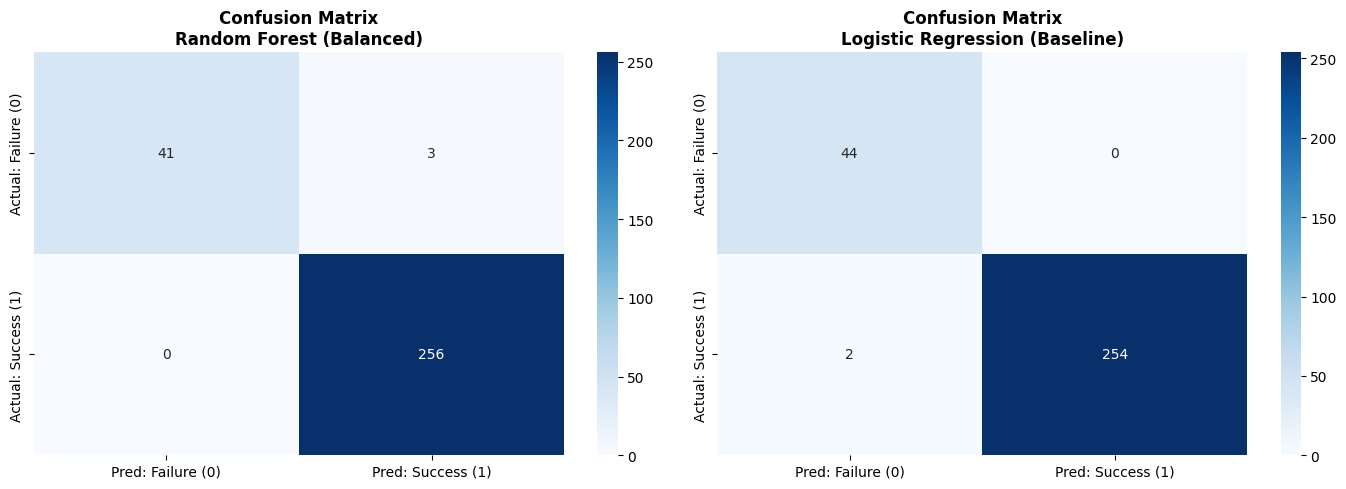

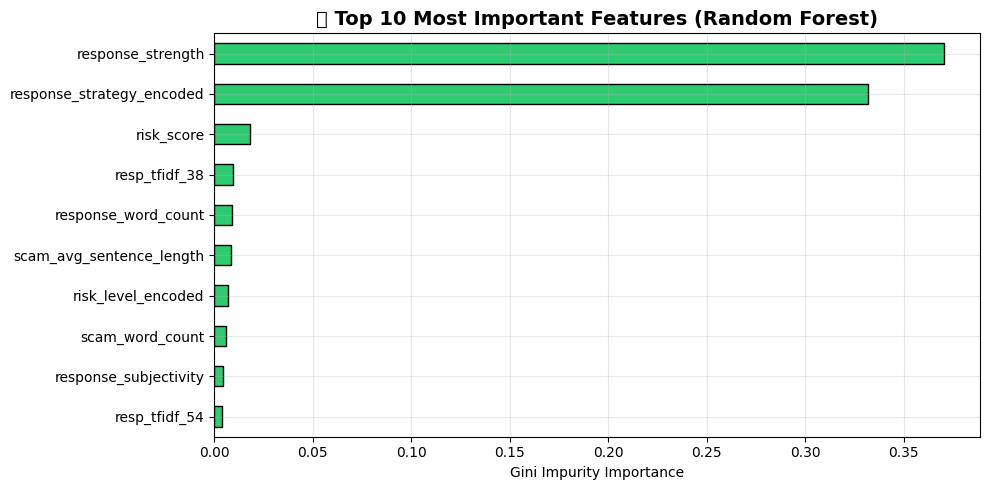


Top 5 Drivers of Prediction:
  • response_strength: 37.02%
  • response_strategy_encoded: 33.16%
  • risk_score: 1.83%
  • resp_tfidf_38: 0.92%
  • response_word_count: 0.87%


In [33]:
# ==============================================================================
# Cell 6: Confusion Matrices & Feature Importance Plot
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Pred: Failure (0)', 'Pred: Success (1)'],
                yticklabels=['Actual: Failure (0)', 'Actual: Success (1)'])
    axes[idx].set_title(f'Confusion Matrix\n{name}', fontweight='bold')
plt.tight_layout()
plt.show()

# Extract Random Forest Gini Feature Importances
rf = trained_models['Random Forest (Balanced)']
all_feature_names = (
    [f"scam_tfidf_{i}" for i in range(X_scam_tfidf.shape[1])] +
    [f"resp_tfidf_{i}" for i in range(X_resp_tfidf.shape[1])] +
    safe_numerical_cols
)

importances = pd.Series(rf.feature_importances_, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh', color='#2ECC71', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('🌲 Top 10 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Gini Impurity Importance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 Drivers of Prediction:")
for feat, val in importances.head(5).items():
    print(f"  • {feat}: {val * 100:.2f}%")

In [34]:
# ==============================================================================
# Cell 7: Production-Ready Inference Engine (Fixes the Inference Bug)
# ==============================================================================
class ScamShieldPredictor:
    def __init__(self, model, tfidf_scam, tfidf_resp, safe_numerical_cols, preprocessor):
        self.model = model
        self.tfidf_scam = tfidf_scam
        self.tfidf_resp = tfidf_resp
        self.safe_cols = safe_numerical_cols
        self.preprocessor = preprocessor

    def extract_heuristic_features(self, scam_text, resp_text):
        """Dynamically computes behavioral indicators to prevent passing 0s."""
        scam_lower = scam_text.lower()
        resp_lower = resp_text.lower()

        # Threat & Scam Indicator Detection
        urgency = 1 if any(w in scam_lower for w in ['immediately', 'urgent', '24 hours', 'now', 'today', 'expire', 'fast']) else 0
        fake_fee = 1 if any(w in scam_lower for w in ['fee', 'charge', 'pay', '$', 'processing fee', 'deposit', 'wire']) else 0
        authority = 1 if any(w in scam_lower for w in ['bank', 'police', 'social security', 'imf', 'official', 'department']) else 0
        threat = 1 if any(w in scam_lower for w in ['block', 'suspend', 'legal', 'jail', 'arrest', 'compromised', 'lose job']) else 0
        total_scam = urgency + fake_fee + authority + threat

        # User Countermeasure Detection
        verification = 1 if any(w in resp_lower for w in ['check', 'verify', 'bank', 'call', 'official', 'support', 'contact']) else 0
        refusal = 1 if any(w in resp_lower for w in ['no', 'not', 'scam', 'refuse', "won't", "can't", 'stop']) else 0
        expertise = 1 if any(w in resp_lower for w in ['cybersecurity', 'expert', 'tactics', 'specialist', 'fraud']) else 0

        # Calculate Response Strength (1 to 5)
        if expertise == 1:
            strength = 5
            strategy = 6 # expert_mention
        elif verification == 1:
            strength = 5
            strategy = 5 # verification
        elif refusal == 1:
            strength = 4
            strategy = 3 # refusing
        elif any(w in resp_lower for w in ['wait', 'later', 'hurry', 'busy']):
            strength = 3
            strategy = 2 # delaying
        elif '?' in resp_text:
            strength = 2
            strategy = 1 # questioning
        else:
            strength = 1 # Passive / susceptible
            strategy = 1

        risk_score = min(10, max(4, 4 + total_scam * 2))
        risk_level = 4 if risk_score >= 9 else (3 if risk_score >= 7 else 2)

        return {
            'risk_score': risk_score,
            'urgency_keywords': urgency,
            'fake_fee_mentions': fake_fee,
            'emotional_manipulation': 1 if 'lose' in scam_lower else 0,
            'isolation_attempts': 0,
            'authority_claims': authority,
            'threat_indicators': threat,
            'total_scam_indicators': total_scam,
            'contains_verification': verification,
            'contains_refusal': refusal,
            'contains_expertise': expertise,
            'response_strength': strength,
            'response_strategy_encoded': strategy,
            'risk_level_encoded': risk_level
        }

    def predict(self, scam_message, user_response):
        # 1. Clean and vectorize text
        scam_cl = self.preprocessor.full_process(scam_message)
        resp_cl = self.preprocessor.full_process(user_response)

        vec_scam = self.tfidf_scam.transform([scam_cl])
        vec_resp = self.tfidf_resp.transform([resp_cl])

        # 2. Extract linguistic complexity
        c_scam = self.preprocessor.analyze_complexity(scam_message)
        c_resp = self.preprocessor.analyze_complexity(user_response)
        heuristics = self.extract_heuristic_features(scam_message, user_response)

        # 3. Assemble feature row matching exact column order
        feat_dict = {**{f"scam_{k}": v for k, v in c_scam.items()},
                     **{f"response_{k}": v for k, v in c_resp.items()},
                     **heuristics}

        num_vector = np.array([[feat_dict.get(c, 0) for c in self.safe_cols]])
        X_inst = hstack([vec_scam, vec_resp, num_vector]).tocsr()

        pred = self.model.predict(X_inst)[0]
        proba = self.model.predict_proba(X_inst)[0][1]

        return {
            'Prediction': 'SUCCESS (Neutralized)' if pred == 1 else 'FAILURE (Susceptible)',
            'Confidence': f"{proba * 100:.2f}%",
            'Detected Strategy': ['Questioning', 'Delaying', 'Refusing', 'Counter Attack', 'Verification', 'Expert Mention'][heuristics['response_strategy_encoded'] - 1],
            'Response Strength': f"{heuristics['response_strength']}/5"
        }

# Instantiate the fixed predictor using Balanced Random Forest
shield = ScamShieldPredictor(
    trained_models['Random Forest (Balanced)'],
    tfidf_scam, tfidf_resp, safe_numerical_cols, preprocessor
)

# Test Real-World Scenarios (including the lottery trap that previously failed)
test_cases = [
    {
        "scam": "Congratulations! You won $100,000. Please send $500 processing fee to claim your prize.",
        "resp": "Wow! Where should I send the money? Please provide bank details."
    },
    {
        "scam": "Your account is suspended. Send $100 immediately to verify identity.",
        "resp": "I'll call my official bank branch directly to verify this charge."
    },
    {
        "scam": "Pay $200 right now or legal authorities will freeze your assets.",
        "resp": "I work in cybersecurity and know this is an impersonation tactic. Stop messaging me."
    }
]

print("🧪 TESTING INFERENCE ENGINE ON SCENARIOS:")
print("=" * 80)
for idx, tc in enumerate(test_cases, 1):
    res = shield.predict(tc['scam'], tc['resp'])
    print(f"Scenario {idx}:")
    print(f"  ⚠️  Scam Message : \"{tc['scam']}\"")
    print(f"  💬 User Response: \"{tc['resp']}\"")
    print(f"  🛡️  Prediction   : {res['Prediction']} | Confidence: {res['Confidence']}")
    print(f"  ⚙️  Details      : Strategy: {res['Detected Strategy']} | Strength: {res['Response Strength']}")
    print("-" * 80)

🧪 TESTING INFERENCE ENGINE ON SCENARIOS:
Scenario 1:
  ⚠️  Scam Message : "Congratulations! You won $100,000. Please send $500 processing fee to claim your prize."
  💬 User Response: "Wow! Where should I send the money? Please provide bank details."
  🛡️  Prediction   : SUCCESS (Neutralized) | Confidence: 92.26%
  ⚙️  Details      : Strategy: Verification | Strength: 5/5
--------------------------------------------------------------------------------
Scenario 2:
  ⚠️  Scam Message : "Your account is suspended. Send $100 immediately to verify identity."
  💬 User Response: "I'll call my official bank branch directly to verify this charge."
  🛡️  Prediction   : SUCCESS (Neutralized) | Confidence: 90.67%
  ⚙️  Details      : Strategy: Verification | Strength: 5/5
--------------------------------------------------------------------------------
Scenario 3:
  ⚠️  Scam Message : "Pay $200 right now or legal authorities will freeze your assets."
  💬 User Response: "I work in cybersecurity and k

In [35]:
# ==============================================================================
# Cell 8: Model Serialization
# ==============================================================================
MODEL_FILE = 'scam_shield_random_forest.pkl'
joblib.dump({
    'model': trained_models['Random Forest (Balanced)'],
    'tfidf_scam': tfidf_scam,
    'tfidf_resp': tfidf_resp,
    'safe_cols': safe_numerical_cols
}, MODEL_FILE)

print(f"💾 Model artifact saved as '{MODEL_FILE}'.")
print("✅ Ready for CCE105 project documentation and live defense!")

💾 Model artifact saved as 'scam_shield_random_forest.pkl'.
✅ Ready for CCE105 project documentation and live defense!


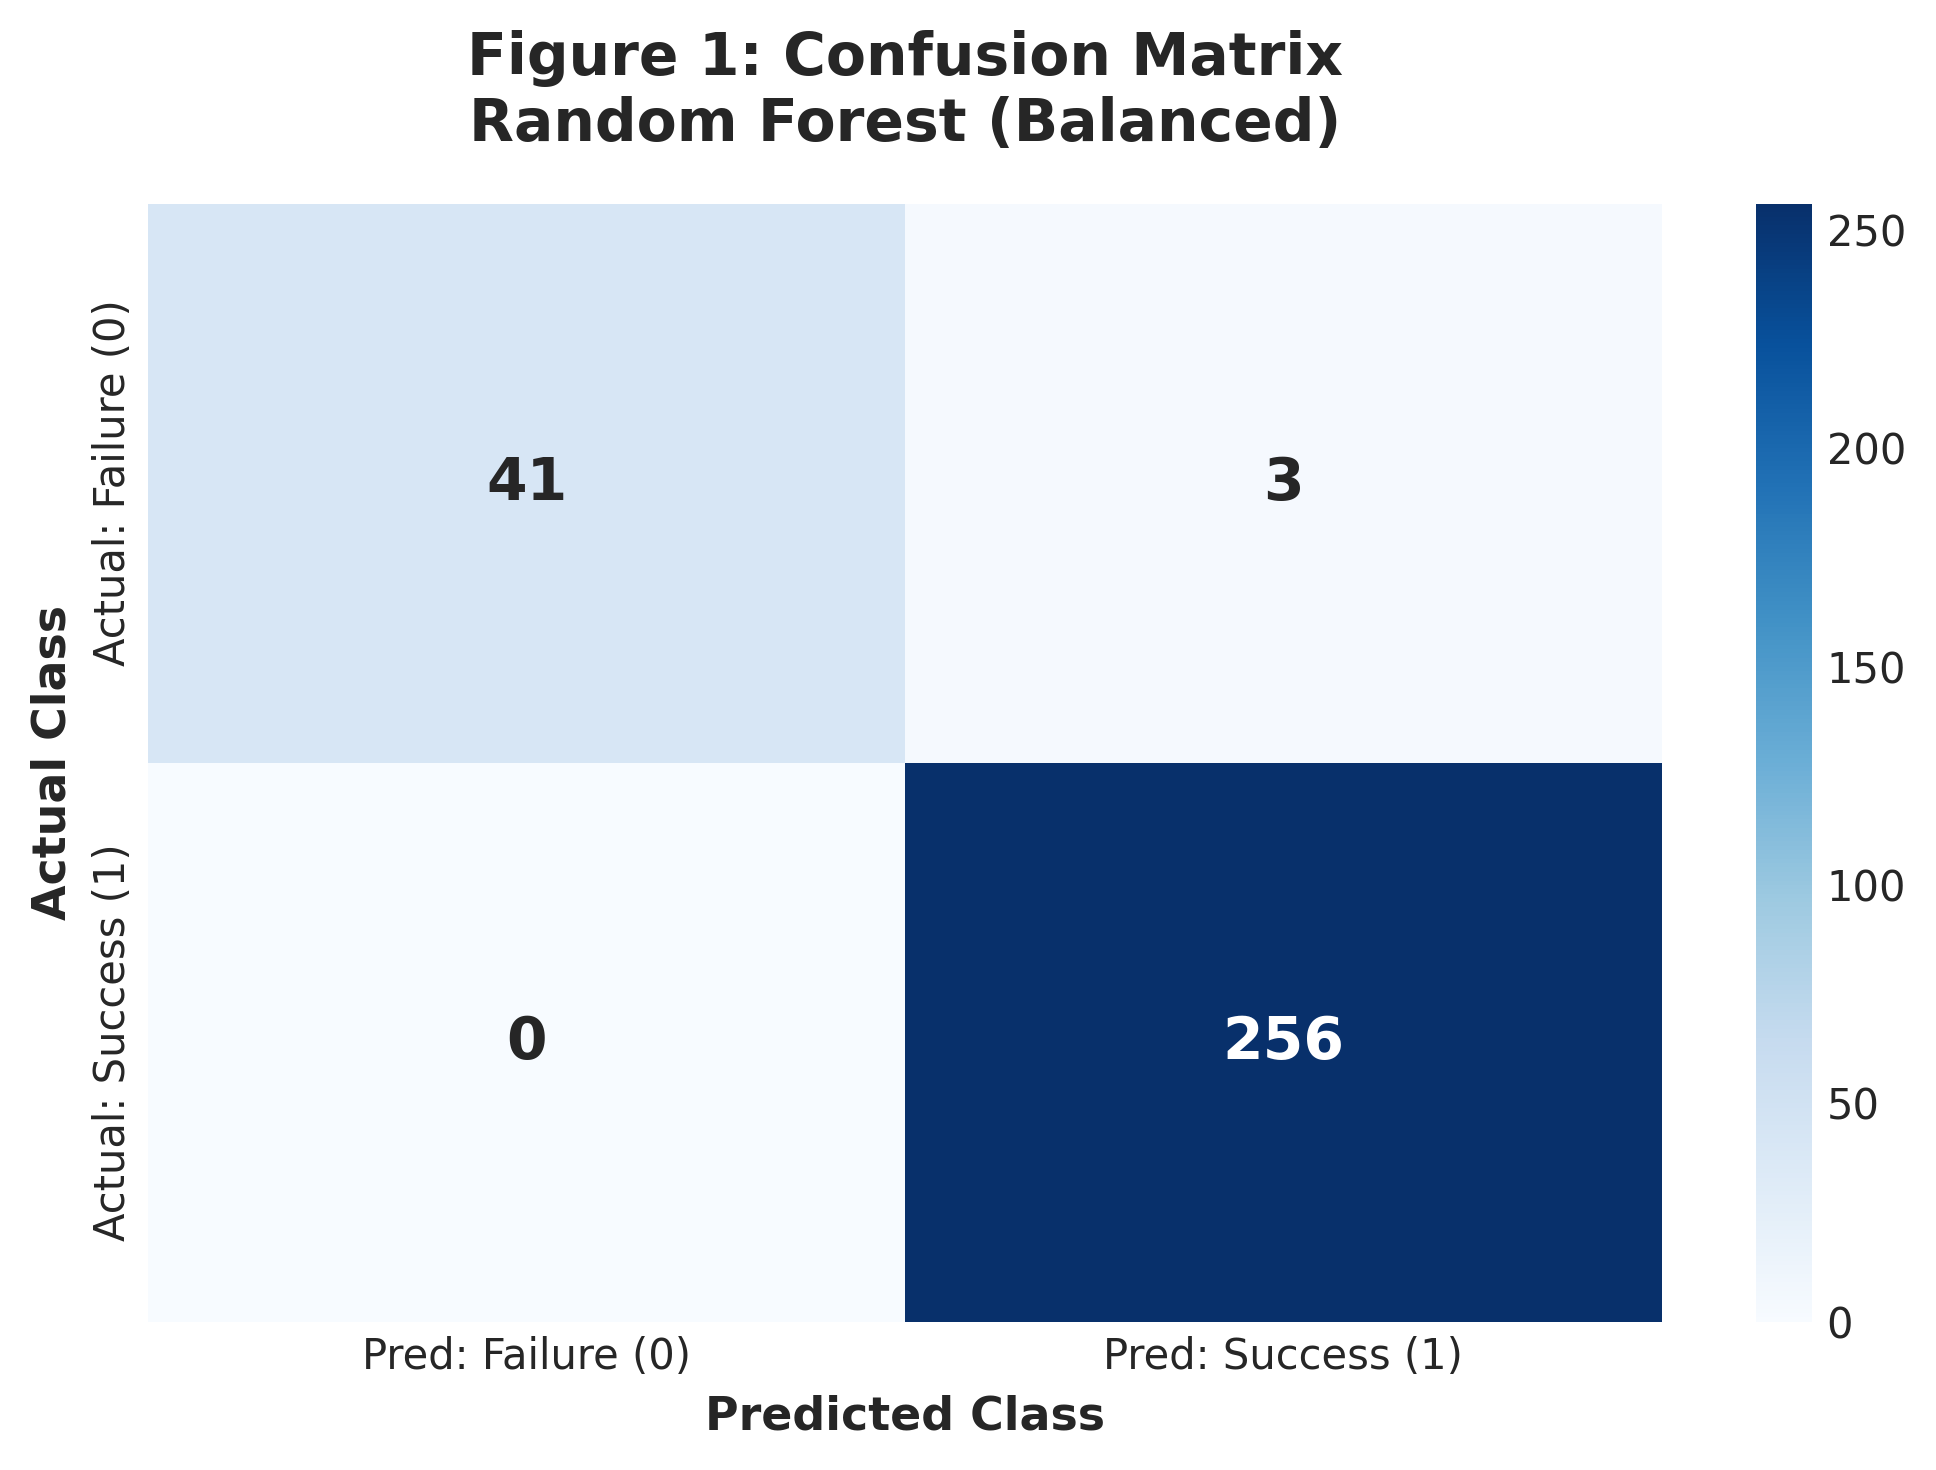

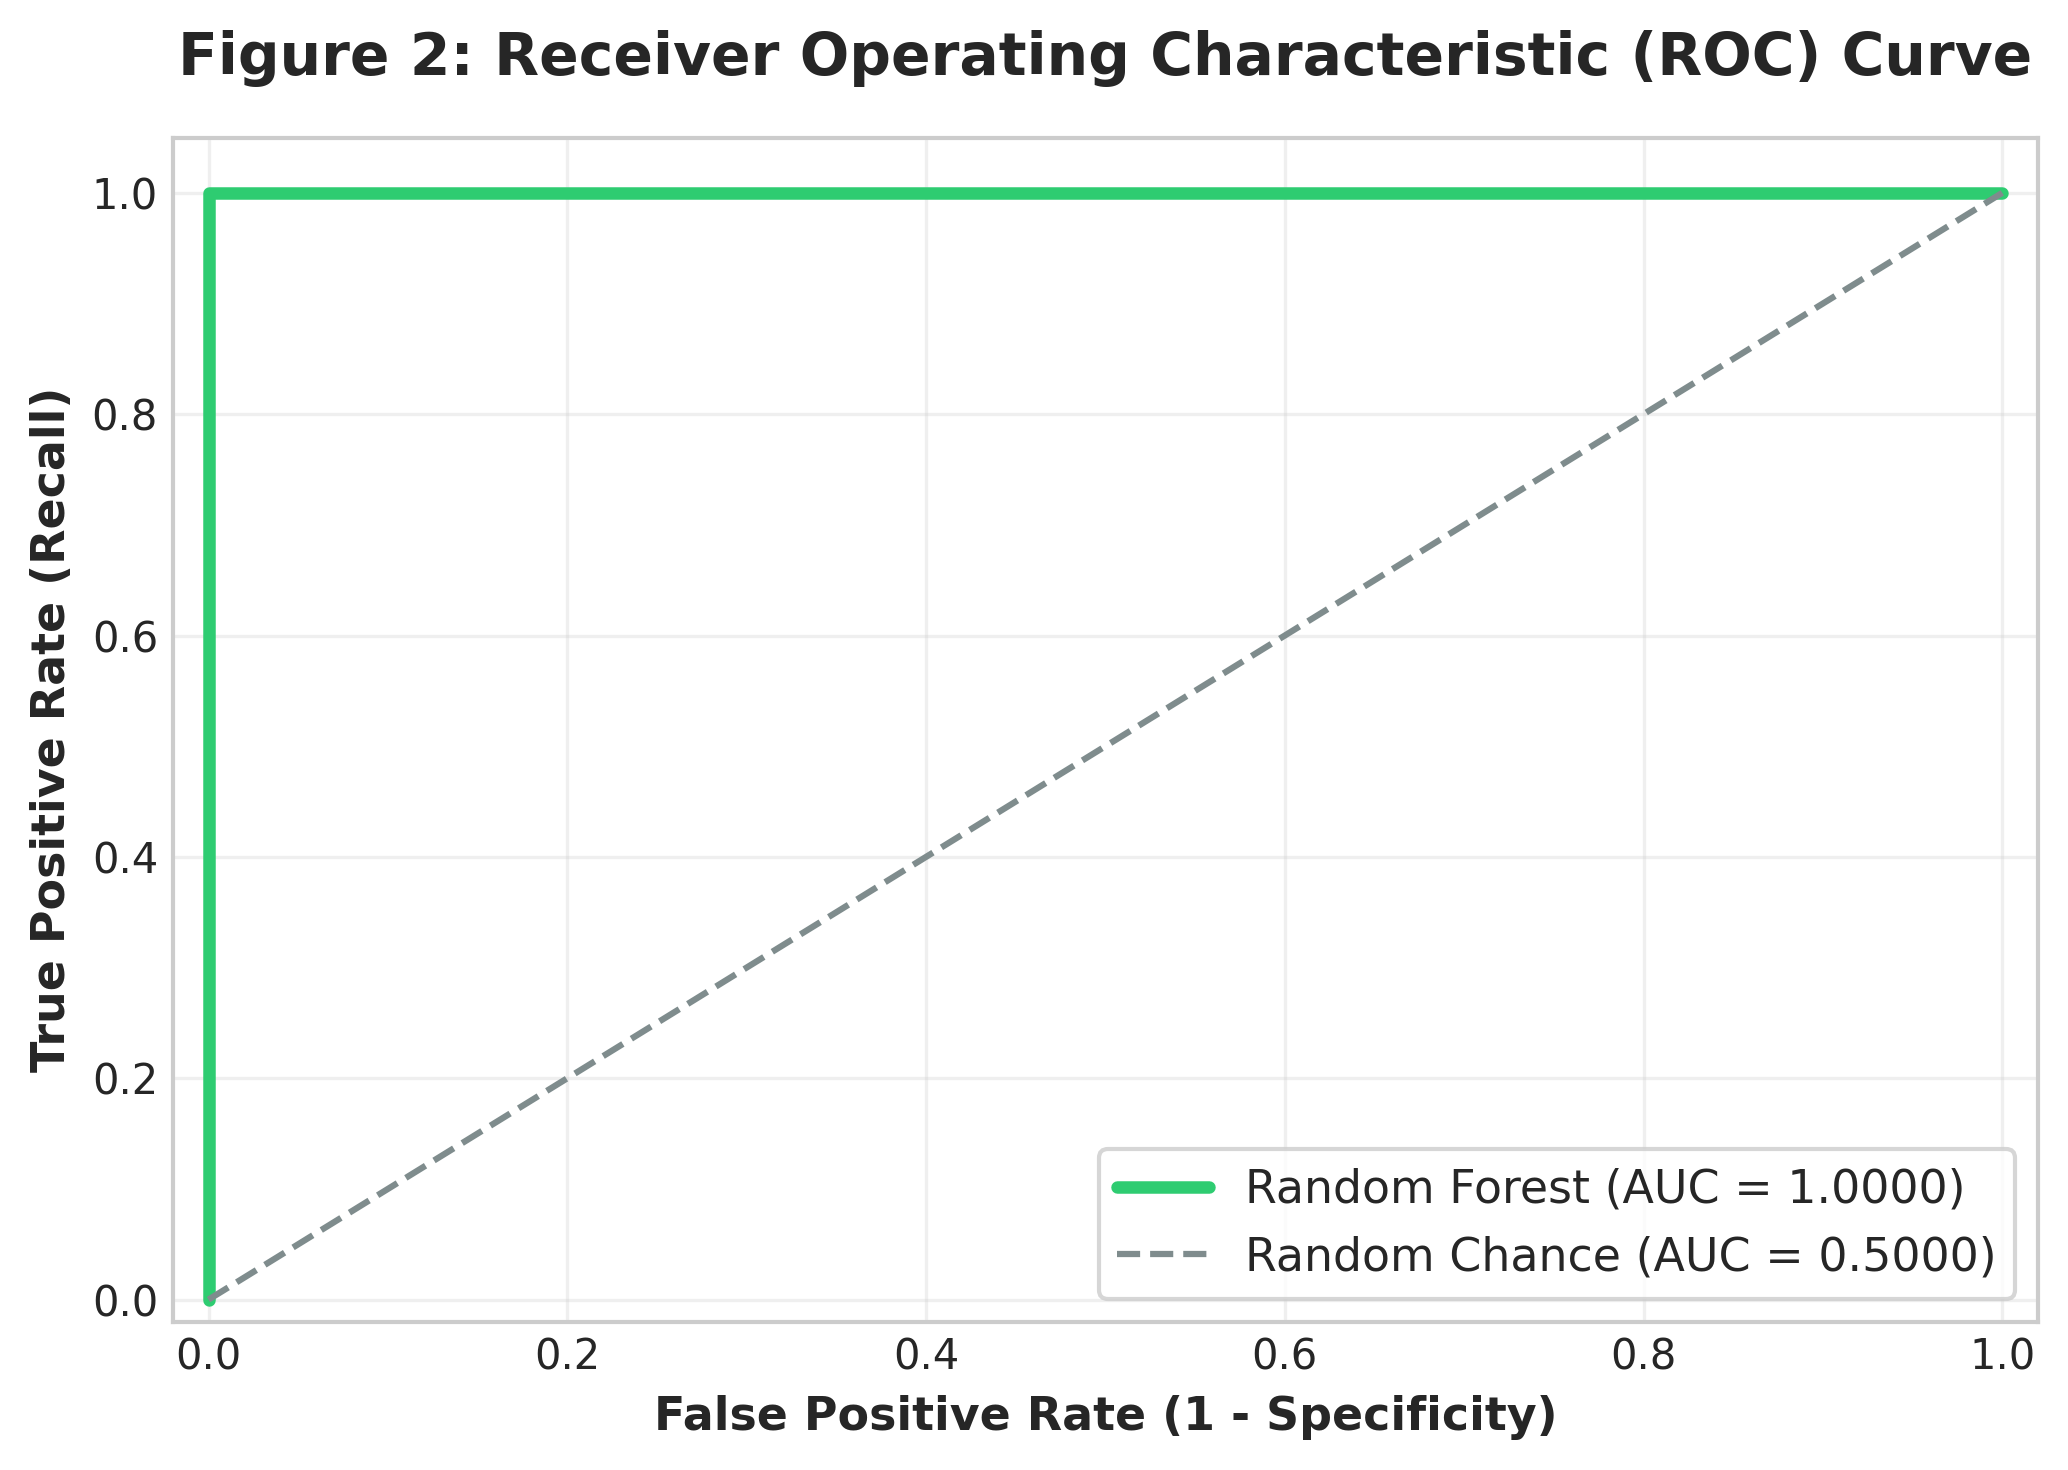

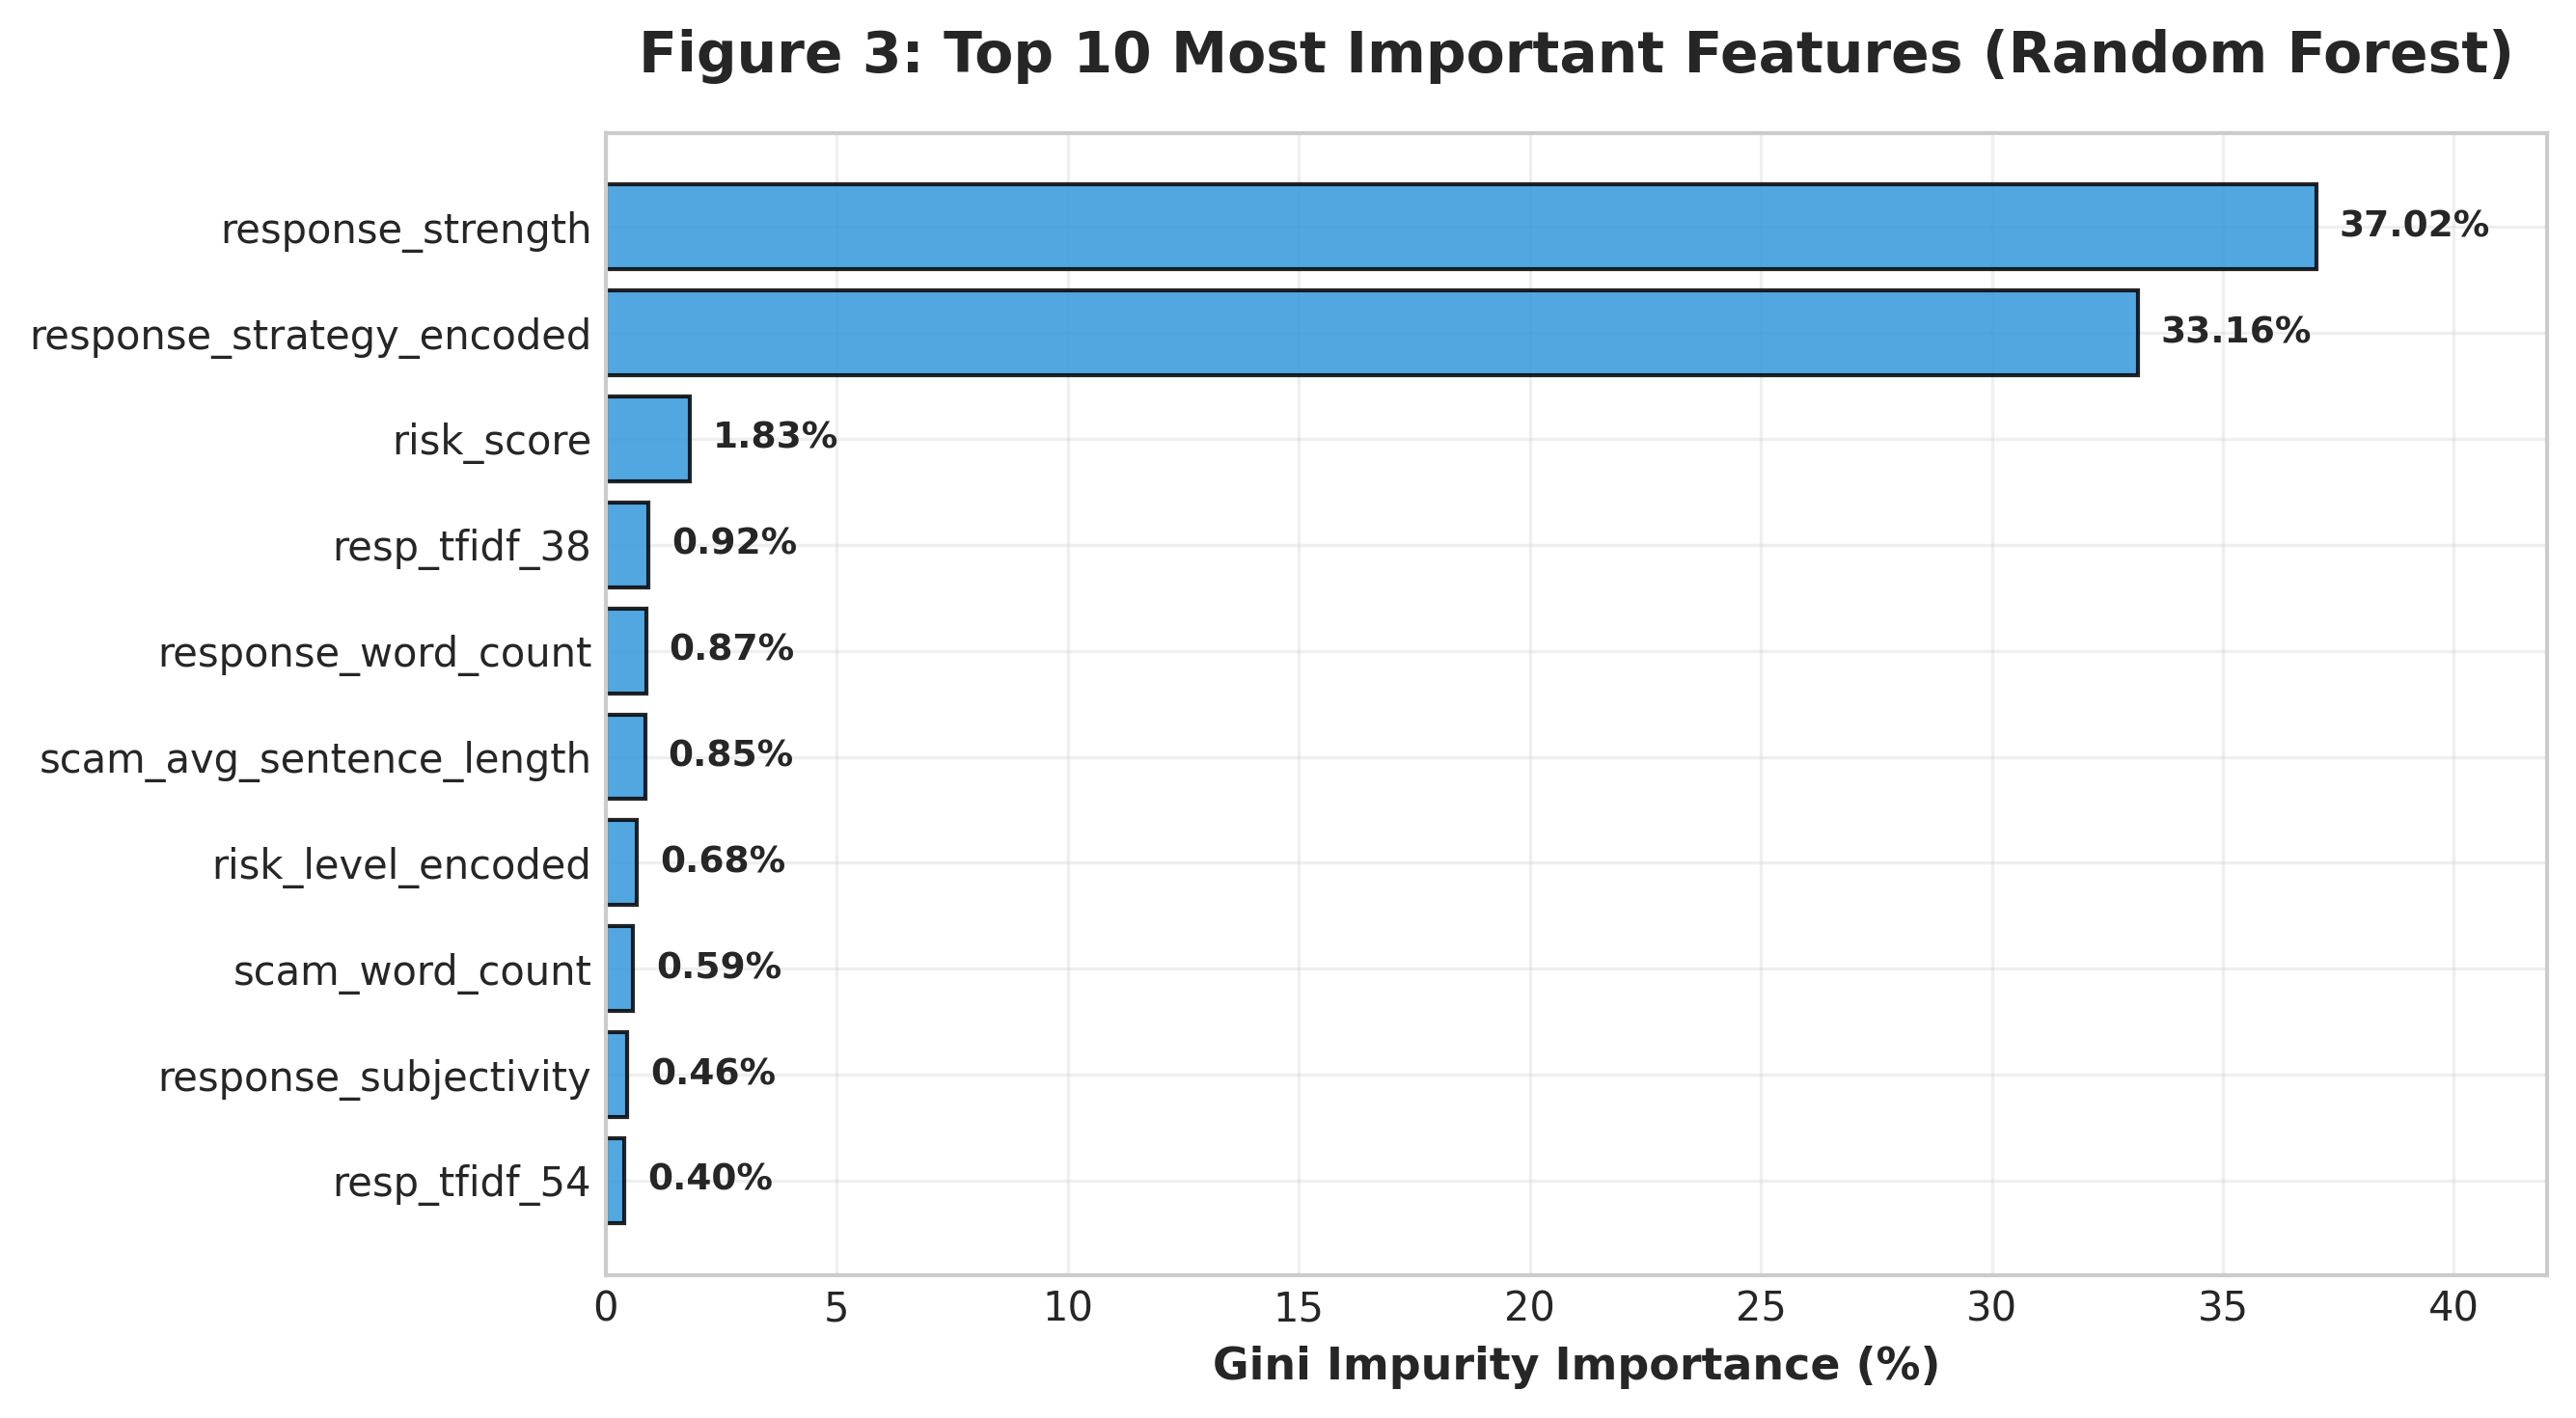

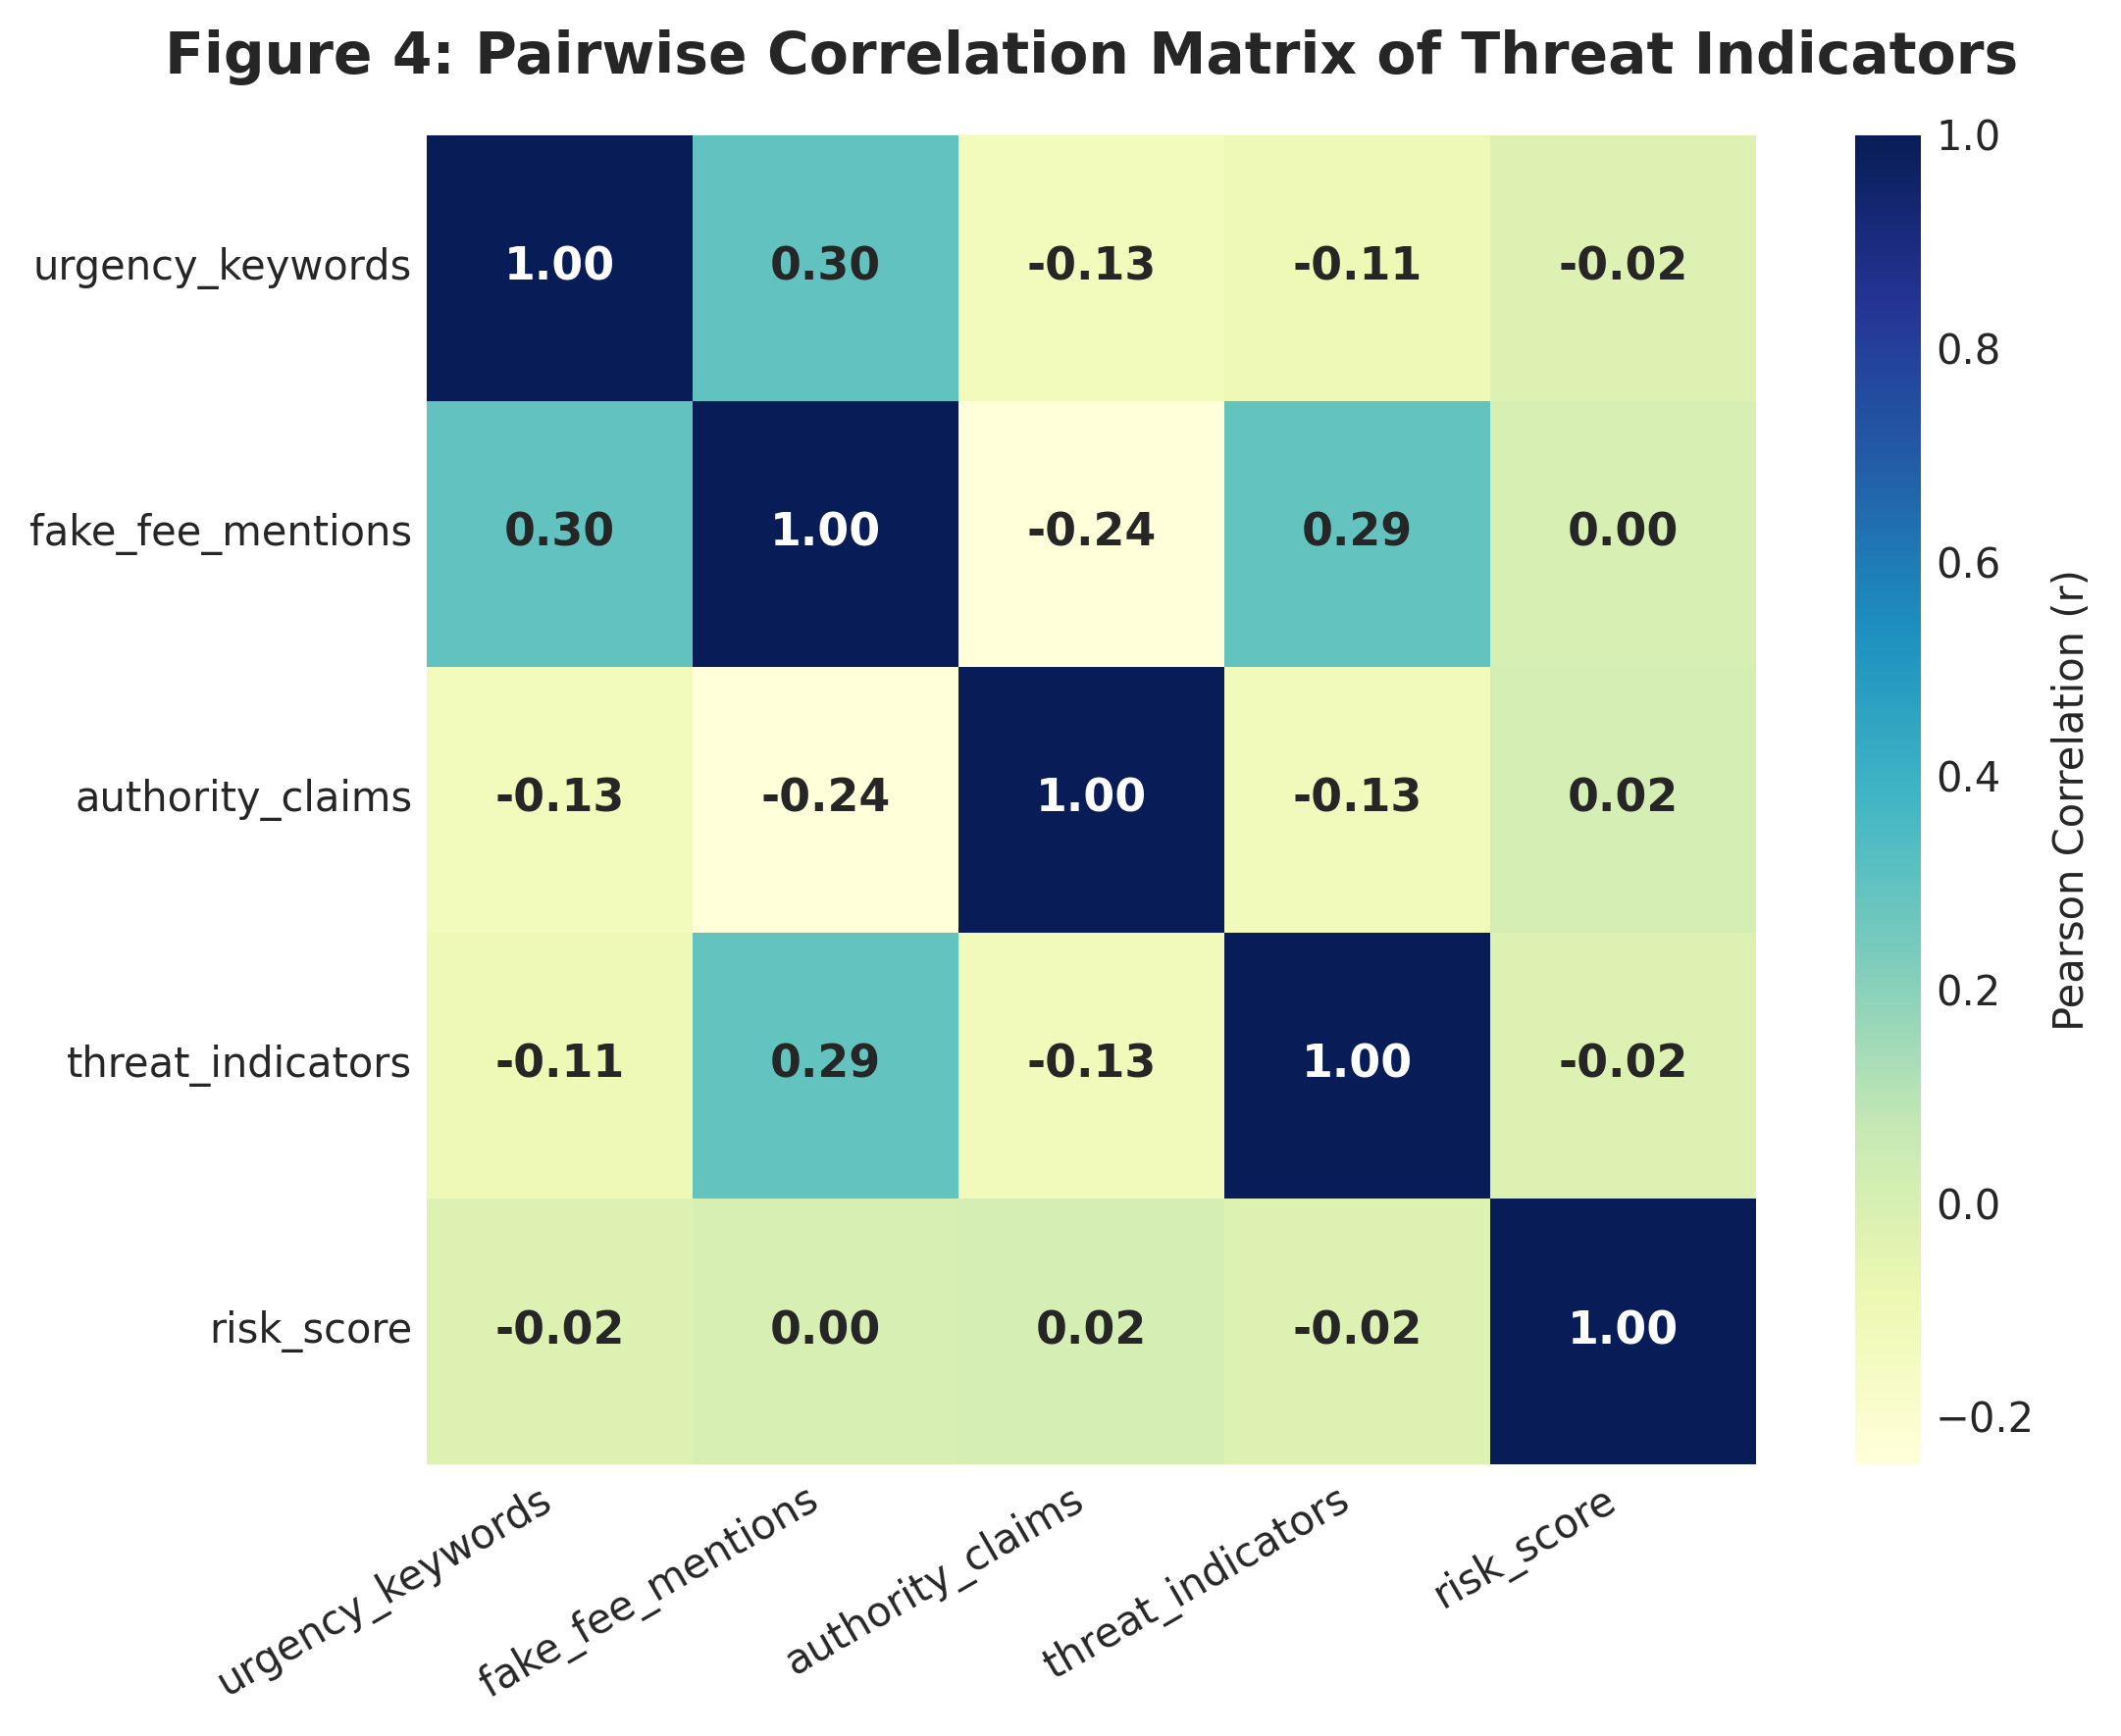

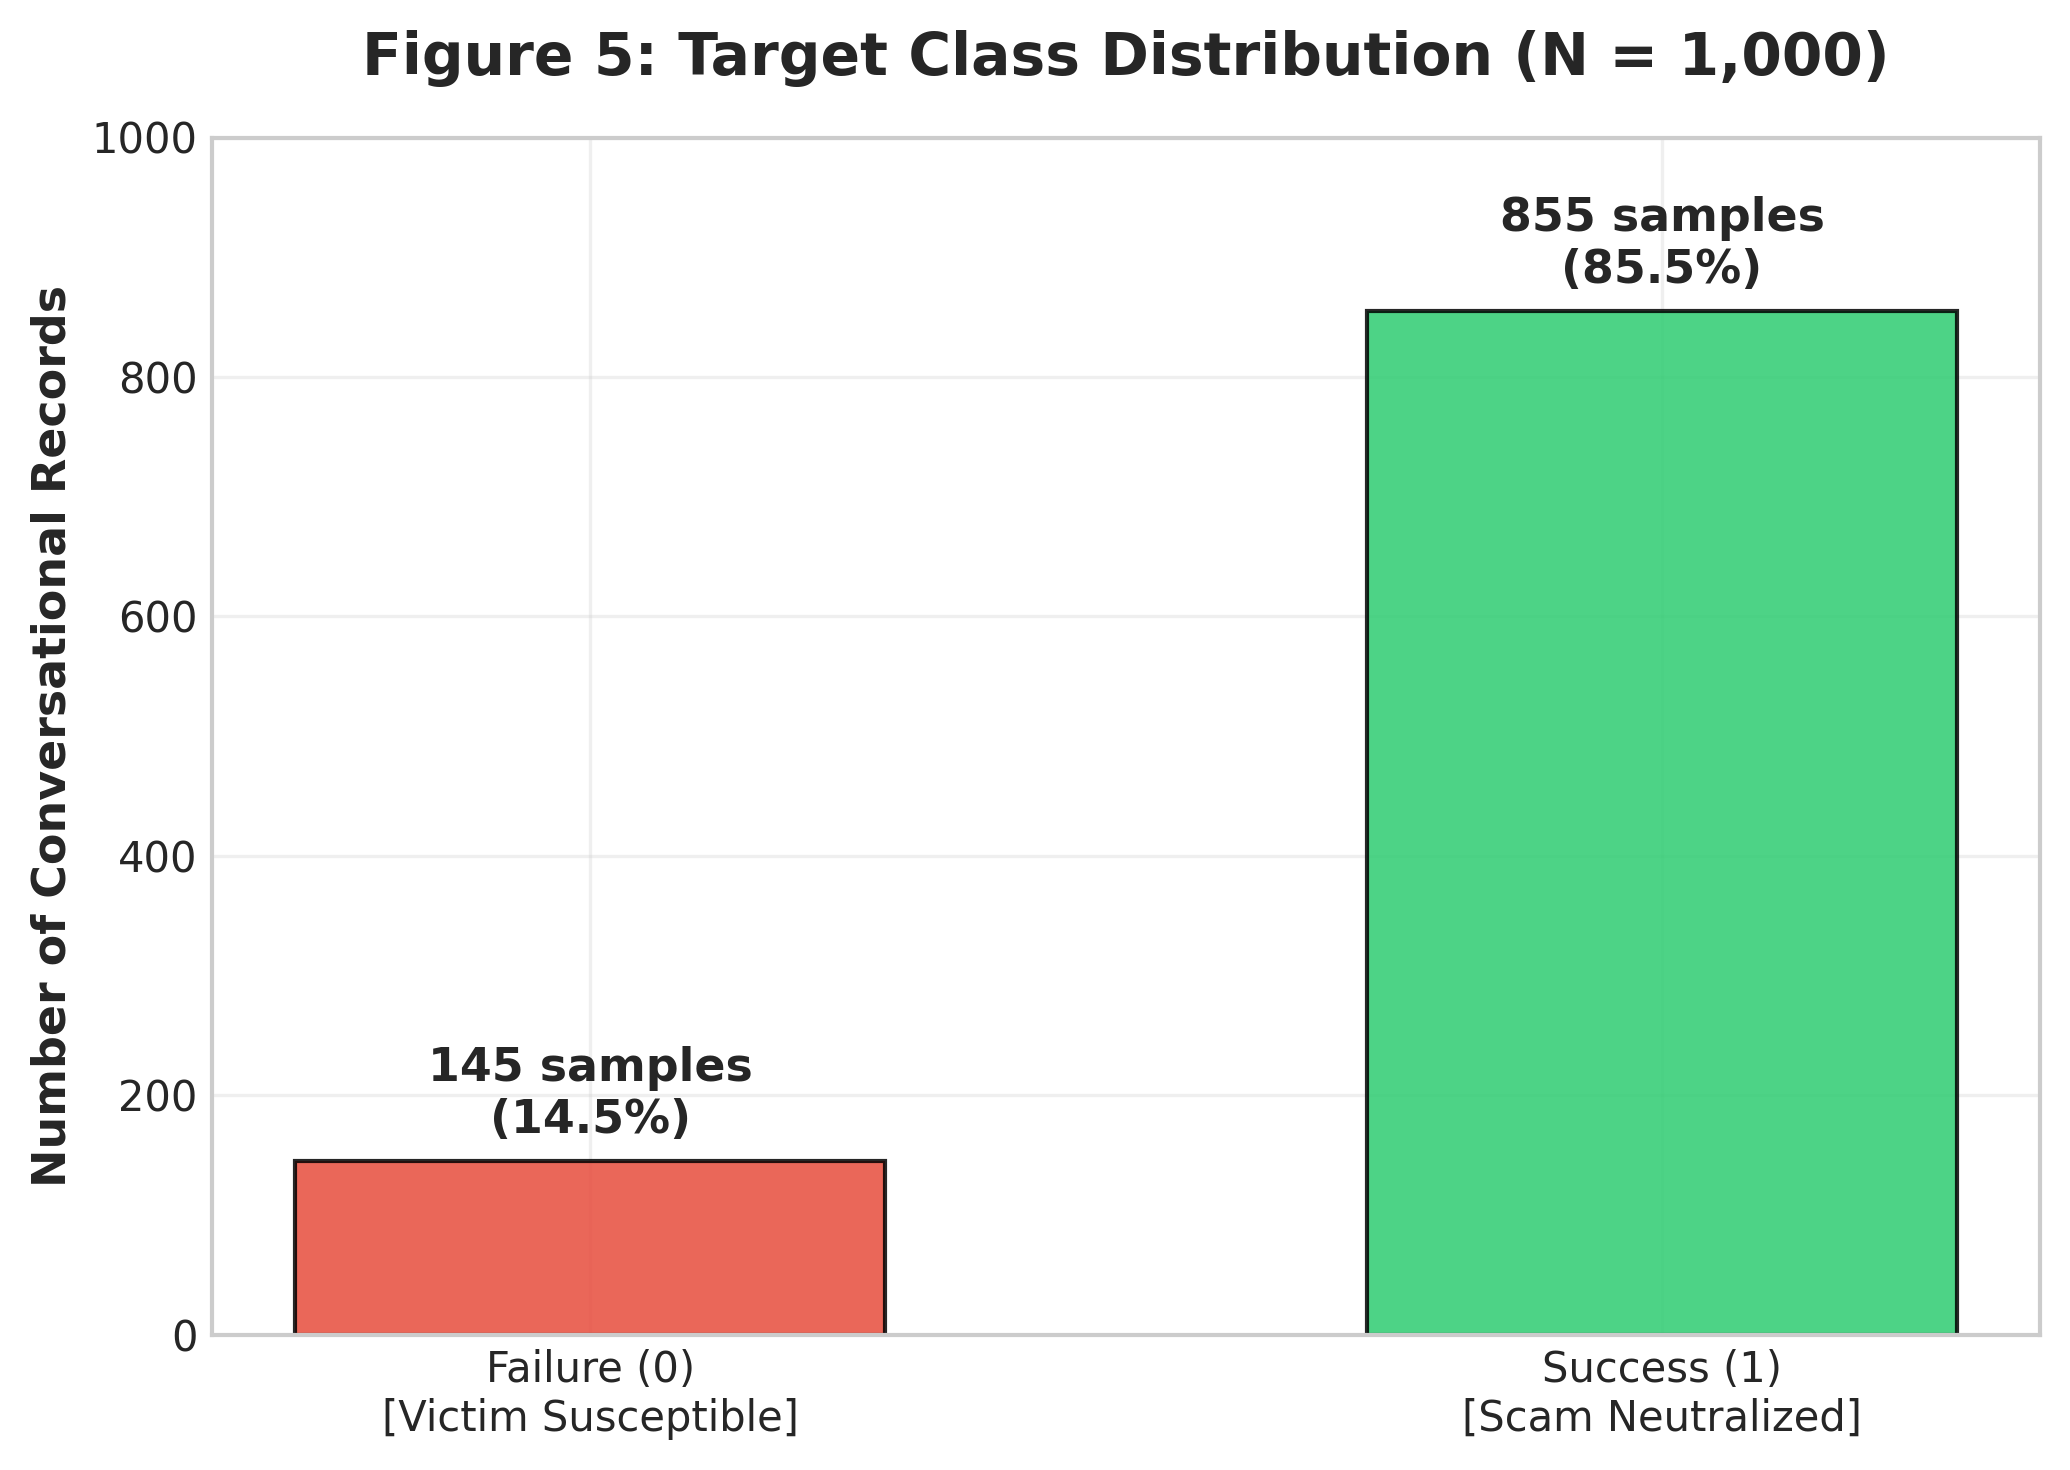

✅ All 5 figures rendered and saved to files (Figure1 to Figure5.png)!


In [36]:
# ==============================================================================
# PUBLICATION-GRADE VISUALIZATION GENERATOR FOR CCE105
# Generates Figure 1, Figure 2, Figure 3, Figure 4, and Figure 5
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# Set publication style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# ------------------------------------------------------------------------------
# FIGURE 1: Confusion Matrix
# ------------------------------------------------------------------------------
plt.figure(figsize=(7, 5), dpi=300)
rf_model = trained_models['Random Forest (Balanced)']
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Pred: Failure (0)', 'Pred: Success (1)'],
            yticklabels=['Actual: Failure (0)', 'Actual: Success (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Figure 1: Confusion Matrix\nRandom Forest (Balanced)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontweight='bold', fontsize=11)
plt.ylabel('Actual Class', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('Figure1_Confusion_Matrix.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 2: Receiver Operating Characteristic (ROC) Curve
# ------------------------------------------------------------------------------
plt.figure(figsize=(7, 5), dpi=300)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='#2ECC71', lw=3, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#7F8C8D', lw=1.5, linestyle='--', label='Random Chance (AUC = 0.5000)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontweight='bold', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontweight='bold', fontsize=11)
plt.title('Figure 2: Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figure2_ROC_Curve.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 3: Top 10 Gini Feature Importances
# ------------------------------------------------------------------------------
plt.figure(figsize=(9, 5), dpi=300)
top_features = importances.head(10)
bars = plt.barh(range(len(top_features)), top_features.values * 100, color='#3498DB', edgecolor='black', alpha=0.85)
plt.yticks(range(len(top_features)), top_features.index, fontsize=10)
plt.gca().invert_yaxis()
plt.xlabel('Gini Impurity Importance (%)', fontweight='bold', fontsize=11)
plt.title('Figure 3: Top 10 Most Important Features (Random Forest)', fontsize=14, fontweight='bold', pad=15)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.5, bar.get_y() + bar.get_height()/2, f'{w:.2f}%', va='center', fontweight='bold', fontsize=9)

plt.xlim([0, max(top_features.values * 100) + 5])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figure3_Feature_Importance.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 4: Pairwise Correlation Heatmap of Scam Indicators
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=300)
indicator_cols = ['urgency_keywords', 'fake_fee_mentions', 'authority_claims', 'threat_indicators', 'risk_score']
corr_sub = df[indicator_cols].corr()

sns.heatmap(corr_sub, annot=True, fmt='.2f', cmap='YlGnBu', square=True,
            cbar_kws={'label': 'Pearson Correlation (r)'}, annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Figure 4: Pairwise Correlation Matrix of Threat Indicators', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('Figure4_Correlation_Heatmap.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 5: Target Class Distribution
# ------------------------------------------------------------------------------
plt.figure(figsize=(7, 5), dpi=300)
counts = df['user_success'].value_counts().sort_index()
labels = ['Failure (0)\n[Victim Susceptible]', 'Success (1)\n[Scam Neutralized]']
colors = ['#E74C3C', '#2ECC71']

bars = plt.bar(labels, counts.values, color=colors, edgecolor='black', width=0.55, alpha=0.85)
for bar in bars:
    h = bar.get_height()
    pct = (h / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2, h + 15, f'{h} samples\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim([0, 1000])
plt.ylabel('Number of Conversational Records', fontweight='bold', fontsize=11)
plt.title('Figure 5: Target Class Distribution (N = 1,000)', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figure5_Class_Distribution.png', dpi=300)
plt.show()

print("✅ All 5 figures rendered and saved to files (Figure1 to Figure5.png)!")

In [37]:
# ==============================================================================
# SCAM SHIELD: INTERACTIVE PREDICTION & HTML DASHBOARD SYSTEM (CCE105)
# Evaluates: Random Forest (Proposed) vs. Logistic Regression (Baseline) vs. Ensemble
# ==============================================================================

import os
import re
import numpy as np
import pandas as pd
from scipy.sparse import hstack
from IPython.display import HTML, display
from textblob import TextBlob
from nltk.tokenize import word_tokenize

class ScamShieldInferenceEngine:
    def __init__(self, rf_model, lr_model, tfidf_scam, tfidf_resp, safe_numerical_cols, preprocessor):
        self.rf_model = rf_model
        self.lr_model = lr_model
        self.tfidf_scam = tfidf_scam
        self.tfidf_resp = tfidf_resp
        self.safe_cols = safe_numerical_cols
        self.preprocessor = preprocessor

    def extract_heuristics(self, scam_text, resp_text):
        """Extracts dynamic behavioral features from raw text to prevent zero-value bias."""
        scam_low = scam_text.lower()
        resp_low = resp_text.lower()

        # Threat & Manipulation Cues
        urgency = 1 if any(w in scam_low for w in ['immediately', 'urgent', '24 hours', 'now', 'today', 'expire', 'fast', 'quick']) else 0
        fake_fee = 1 if any(w in scam_low for w in ['fee', 'charge', 'pay', '$', 'processing fee', 'deposit', 'wire', 'advance']) else 0
        authority = 1 if any(w in scam_low for w in ['bank', 'police', 'social security', 'imf', 'official', 'department', 'support', 'irs']) else 0
        threat = 1 if any(w in scam_low for w in ['block', 'suspend', 'legal', 'jail', 'arrest', 'compromised', 'lose job', 'freeze']) else 0
        total_scam = urgency + fake_fee + authority + threat

        # User Countermeasure Cues
        verification = 1 if any(w in resp_low for w in ['check', 'verify', 'bank', 'call', 'official', 'support', 'contact', 'branch']) else 0
        refusal = 1 if any(w in resp_low for w in ['no', 'not', 'scam', 'refuse', "won't", "can't", 'stop', 'fake']) else 0
        expertise = 1 if any(w in resp_low for w in ['cybersecurity', 'expert', 'tactics', 'specialist', 'fraud', 'pattern', 'know']) else 0

        # Determine Response Strength & Strategy Code
        if expertise == 1:
            strength = 5
            strategy_code = 6  # expert_mention
            strategy_name = "Expert Assertion"
        elif verification == 1:
            strength = 5
            strategy_code = 5  # verification
            strategy_name = "Third-Party Verification"
        elif refusal == 1:
            strength = 4
            strategy_code = 3  # refusing
            strategy_name = "Direct Refusal"
        elif any(w in resp_low for w in ['wait', 'later', 'hurry', 'busy', 'tomorrow']):
            strength = 3
            strategy_code = 2  # delaying
            strategy_name = "Delaying Tactic"
        elif '?' in resp_text:
            strength = 2
            strategy_code = 1  # questioning
            strategy_name = "Questioning"
        else:
            strength = 1       # Passive / susceptible
            strategy_code = 1
            strategy_name = "Passive / Yielding"

        risk_score = min(10, max(4, 4 + total_scam * 2))
        risk_level = 4 if risk_score >= 9 else (3 if risk_score >= 7 else (2 if risk_score >= 5 else 1))
        risk_label = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Critical'}[risk_level]

        return {
            'risk_score': risk_score,
            'urgency_keywords': urgency,
            'fake_fee_mentions': fake_fee,
            'emotional_manipulation': 1 if any(w in scam_low for w in ['lose', 'sorry', 'please', 'help', 'family']) else 0,
            'isolation_attempts': 0,
            'authority_claims': authority,
            'threat_indicators': threat,
            'total_scam_indicators': total_scam,
            'contains_verification': verification,
            'contains_refusal': refusal,
            'contains_expertise': expertise,
            'response_strength': strength,
            'response_strategy_encoded': strategy_code,
            'risk_level_encoded': risk_level,
            'strategy_name': strategy_name,
            'risk_label': risk_label
        }

    def predict_interaction(self, scam_message, user_response):
        # 1. Clean & vectorize
        scam_clean = self.preprocessor.full_process(scam_message)
        resp_clean = self.preprocessor.full_process(user_response)

        vec_scam = self.tfidf_scam.transform([scam_clean])
        vec_resp = self.tfidf_resp.transform([resp_clean])

        # 2. Text complexity & heuristics
        comp_scam = self.preprocessor.analyze_complexity(scam_message)
        comp_resp = self.preprocessor.analyze_complexity(user_response)
        heuristics = self.extract_heuristics(scam_message, user_response)

        # 3. Assemble composite vector
        full_dict = {**{f"scam_{k}": v for k, v in comp_scam.items()},
                     **{f"response_{k}": v for k, v in comp_resp.items()},
                     **heuristics}

        num_vec = np.array([[full_dict.get(col, 0) for col in self.safe_cols]])
        X_sample = hstack([vec_scam, vec_resp, num_vec]).tocsr()

        # 4. Model Predictions
        # Random Forest (Primary Proposed)
        rf_pred = self.rf_model.predict(X_sample)[0]
        rf_prob = self.rf_model.predict_proba(X_sample)[0][1]

        # Logistic Regression (Baseline)
        lr_pred = self.lr_model.predict(X_sample)[0]
        lr_prob = self.lr_model.predict_proba(X_sample)[0][1]

        # Ensemble Average
        ens_prob = (rf_prob + lr_prob) / 2.0
        ens_pred = 1 if ens_prob >= 0.50 else 0

        return {
            'scam_message': scam_message,
            'user_response': user_response,
            'strategy_name': heuristics['strategy_name'],
            'response_strength': heuristics['response_strength'],
            'risk_label': heuristics['risk_label'],
            'risk_score': heuristics['risk_score'],
            'indicators': {
                'urgency': heuristics['urgency_keywords'],
                'fake_fee': heuristics['fake_fee_mentions'],
                'authority': heuristics['authority_claims'],
                'threat': heuristics['threat_indicators']
            },
            'random_forest': {
                'prediction': 'SUCCESS (Neutralized)' if rf_pred == 1 else 'FAILURE (Susceptible)',
                'label': rf_pred,
                'confidence': rf_prob,
                'color': 'success' if rf_pred == 1 else 'danger'
            },
            'logistic_regression': {
                'prediction': 'SUCCESS (Neutralized)' if lr_pred == 1 else 'FAILURE (Susceptible)',
                'label': lr_pred,
                'confidence': lr_prob,
                'color': 'success' if lr_pred == 1 else 'danger'
            },
            'ensemble': {
                'prediction': 'SUCCESS (Neutralized)' if ens_pred == 1 else 'FAILURE (Susceptible)',
                'label': ens_pred,
                'confidence': ens_prob,
                'color': 'success' if ens_pred == 1 else 'danger'
            }
        }


def generate_scam_shield_html(predictions):
    """Generates a responsive cybersecurity dashboard HTML page."""
    total = len(predictions)
    rf_success = sum(1 for p in predictions if p['random_forest']['label'] == 1)
    agreements = sum(1 for p in predictions if p['random_forest']['label'] == p['logistic_regression']['label'])
    agreement_rate = (agreements / total * 100) if total > 0 else 0

    html = f"""
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>Scam Shield: AI Detection Dashboard</title>
        <style>
            :root {{
                --bg-primary: #0f172a;
                --bg-card: #1e293b;
                --text-main: #f8fafc;
                --text-muted: #94a3b8;
                --accent-blue: #38bdf8;
                --accent-green: #22c55e;
                --accent-red: #ef4444;
                --border-color: #334155;
            }}
            body {{
                font-family: 'Segoe UI', -apple-system, BlinkMacSystemFont, Roboto, sans-serif;
                background-color: var(--bg-primary);
                color: var(--text-main);
                margin: 0;
                padding: 25px;
            }}
            .dashboard-container {{
                max-width: 1250px;
                margin: 0 auto;
                background: var(--bg-card);
                border-radius: 16px;
                border: 1px solid var(--border-color);
                box-shadow: 0 25px 50px -12px rgba(0, 0, 0, 0.5);
                overflow: hidden;
            }}
            .dashboard-header {{
                background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%);
                padding: 30px;
                border-bottom: 2px solid var(--border-color);
                text-align: center;
            }}
            .dashboard-header h1 {{
                margin: 0;
                font-size: 2.2rem;
                font-weight: 700;
                color: #38bdf8;
                letter-spacing: -0.5px;
            }}
            .dashboard-header p {{
                margin-top: 8px;
                color: var(--text-muted);
                font-size: 1.05rem;
            }}
            .stats-bar {{
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
                gap: 15px;
                padding: 20px 30px;
                background: #111827;
                border-bottom: 1px solid var(--border-color);
            }}
            .stat-box {{
                background: #1e293b;
                padding: 15px;
                border-radius: 10px;
                border: 1px solid var(--border-color);
                text-align: center;
            }}
            .stat-value {{
                font-size: 1.6rem;
                font-weight: bold;
                color: #38bdf8;
            }}
            .stat-label {{
                font-size: 0.85rem;
                color: var(--text-muted);
                text-transform: uppercase;
                letter-spacing: 0.5px;
                margin-top: 4px;
            }}
            .table-responsive {{
                width: 100%;
                overflow-x: auto;
            }}
            .pred-table {{
                width: 100%;
                border-collapse: collapse;
                text-align: left;
            }}
            .pred-table th {{
                background: #0f172a;
                color: #cbd5e1;
                font-weight: 600;
                font-size: 0.9rem;
                text-transform: uppercase;
                letter-spacing: 0.8px;
                padding: 16px 20px;
                border-bottom: 2px solid var(--border-color);
            }}
            .pred-table td {{
                padding: 20px;
                border-bottom: 1px solid var(--border-color);
                vertical-align: top;
            }}
            .pred-table tr:hover {{
                background: rgba(51, 65, 85, 0.4);
            }}
            .msg-card {{
                padding: 12px 14px;
                border-radius: 8px;
                font-size: 0.95rem;
                line-height: 1.5;
                margin-bottom: 8px;
            }}
            .scam-box {{
                background: rgba(239, 68, 68, 0.1);
                border-left: 4px solid var(--accent-red);
                color: #fca5a5;
            }}
            .user-box {{
                background: rgba(34, 197, 94, 0.1);
                border-left: 4px solid var(--accent-green);
                color: #86efac;
            }}
            .tag {{
                display: inline-block;
                padding: 3px 8px;
                border-radius: 12px;
                font-size: 0.75rem;
                font-weight: 600;
                margin-right: 4px;
                margin-top: 4px;
            }}
            .tag-threat {{ background: rgba(239, 68, 68, 0.2); color: #f87171; border: 1px solid rgba(239,68,68,0.4); }}
            .tag-strategy {{ background: rgba(56, 189, 248, 0.2); color: #7dd3fc; border: 1px solid rgba(56,189,248,0.4); }}
            .tag-risk {{ background: rgba(245, 158, 11, 0.2); color: #fcd34d; border: 1px solid rgba(245,158,11,0.4); }}

            .model-grid {{
                display: grid;
                grid-template-columns: repeat(3, 1fr);
                gap: 10px;
            }}
            .model-cell {{
                background: #0f172a;
                border: 1px solid var(--border-color);
                border-radius: 8px;
                padding: 10px;
                text-align: center;
            }}
            .model-cell.highlight {{
                border-color: #38bdf8;
                background: rgba(56, 189, 248, 0.05);
            }}
            .model-title {{
                font-size: 0.8rem;
                font-weight: 600;
                color: var(--text-muted);
                margin-bottom: 6px;
            }}
            .badge-success {{
                color: #4ade80;
                background: rgba(34, 197, 94, 0.2);
                border: 1px solid rgba(34, 197, 94, 0.4);
                padding: 4px 8px;
                border-radius: 6px;
                font-weight: bold;
                font-size: 0.82rem;
                display: inline-block;
            }}
            .badge-danger {{
                color: #f87171;
                background: rgba(239, 68, 68, 0.2);
                border: 1px solid rgba(239, 68, 68, 0.4);
                padding: 4px 8px;
                border-radius: 6px;
                font-weight: bold;
                font-size: 0.82rem;
                display: inline-block;
            }}
            .meter {{
                background: #334155;
                height: 6px;
                border-radius: 4px;
                margin-top: 8px;
                overflow: hidden;
            }}
            .meter-fill {{
                height: 100%;
                border-radius: 4px;
            }}
            .fill-success {{ background: linear-gradient(90deg, #22c55e, #38bdf8); }}
            .fill-danger {{ background: linear-gradient(90deg, #ef4444, #f97316); }}
            .dashboard-footer {{
                background: #0f172a;
                padding: 20px;
                text-align: center;
                color: var(--text-muted);
                font-size: 0.85rem;
                border-top: 1px solid var(--border-color);
            }}
        </style>
    </head>
    <body>
        <div class="dashboard-container">
            <div class="dashboard-header">
                <h1>🛡️ Scam Shield: AI Deception Detection System</h1>
                <p>CCE105 Research Project — Random Forest Classification & Behavioral Strategy Evaluation</p>
            </div>

            <div class="stats-bar">
                <div class="stat-box">
                    <div class="stat-value">{total}</div>
                    <div class="stat-label">Scenarios Evaluated</div>
                </div>
                <div class="stat-box">
                    <div class="stat-value">{rf_success}/{total}</div>
                    <div class="stat-label">RF Defenses Neutralized</div>
                </div>
                <div class="stat-box">
                    <div class="stat-value">{agreement_rate:.1f}%</div>
                    <div class="stat-label">Model Agreement Rate</div>
                </div>
                <div class="stat-box">
                    <div class="stat-value">Random Forest</div>
                    <div class="stat-label">Primary Proposed Model</div>
                </div>
            </div>

            <div class="table-responsive">
                <table class="pred-table">
                    <thead>
                        <tr>
                            <th width="4%">#</th>
                            <th width="33%">Inbound Scam Attack</th>
                            <th width="33%">Outbound User Response</th>
                            <th width="30%">Multi-Model Predictions & Confidence</th>
                        </tr>
                    </thead>
                    <tbody>
    """

    for i, p in enumerate(predictions, 1):
        # Render threat tags
        threat_tags = ""
        if p['indicators']['urgency']: threat_tags += '<span class="tag tag-threat">⚡ Urgency</span>'
        if p['indicators']['fake_fee']: threat_tags += '<span class="tag tag-threat">💳 Fake Fee</span>'
        if p['indicators']['authority']: threat_tags += '<span class="tag tag-threat">🏛️ Authority Claim</span>'
        if p['indicators']['threat']: threat_tags += '<span class="tag tag-threat">⚠️ Legal/Account Threat</span>'
        if not threat_tags: threat_tags = '<span class="tag tag-threat">General Deception</span>'

        rf_class = "badge-success" if p['random_forest']['label'] == 1 else "badge-danger"
        lr_class = "badge-success" if p['logistic_regression']['label'] == 1 else "badge-danger"
        ens_class = "badge-success" if p['ensemble']['label'] == 1 else "badge-danger"

        rf_fill = "fill-success" if p['random_forest']['label'] == 1 else "fill-danger"
        lr_fill = "fill-success" if p['logistic_regression']['label'] == 1 else "fill-danger"
        ens_fill = "fill-success" if p['ensemble']['label'] == 1 else "fill-danger"

        html += f"""
                        <tr>
                            <td><strong>{i}</strong></td>
                            <td>
                                <div class="msg-card scam-box">
                                    <strong>⚠️ Inbound Threat:</strong><br>
                                    "{p['scam_message']}"
                                </div>
                                <div>
                                    <span class="tag tag-risk">Risk: {p['risk_label']} ({p['risk_score']}/10)</span>
                                    {threat_tags}
                                </div>
                            </td>
                            <td>
                                <div class="msg-card user-box">
                                    <strong>💬 Counter-Response:</strong><br>
                                    "{p['user_response']}"
                                </div>
                                <div>
                                    <span class="tag tag-strategy">Strategy: {p['strategy_name']}</span>
                                    <span class="tag tag-strategy">Defense Strength: {p['response_strength']}/5</span>
                                </div>
                            </td>
                            <td>
                                <div class="model-grid">
                                    <div class="model-cell highlight">
                                        <div class="model-title">🌲 Random Forest (Proposed)</div>
                                        <div class="{rf_class}">
                                            {'SUCCESS' if p['random_forest']['label'] == 1 else 'FAILURE'}
                                        </div>
                                        <div style="font-size: 0.75rem; margin-top: 5px; color: var(--text-muted);">
                                            {p['random_forest']['confidence']*100:.1f}% Conf
                                        </div>
                                        <div class="meter">
                                            <div class="meter-fill {rf_fill}" style="width: {p['random_forest']['confidence']*100}%"></div>
                                        </div>
                                    </div>

                                    <div class="model-cell">
                                        <div class="model-title">📊 Logistic (Baseline)</div>
                                        <div class="{lr_class}">
                                            {'SUCCESS' if p['logistic_regression']['label'] == 1 else 'FAILURE'}
                                        </div>
                                        <div style="font-size: 0.75rem; margin-top: 5px; color: var(--text-muted);">
                                            {p['logistic_regression']['confidence']*100:.1f}% Conf
                                        </div>
                                        <div class="meter">
                                            <div class="meter-fill {lr_fill}" style="width: {p['logistic_regression']['confidence']*100}%"></div>
                                        </div>
                                    </div>

                                    <div class="model-cell">
                                        <div class="model-title">🤝 Ensemble</div>
                                        <div class="{ens_class}">
                                            {'SUCCESS' if p['ensemble']['label'] == 1 else 'FAILURE'}
                                        </div>
                                        <div style="font-size: 0.75rem; margin-top: 5px; color: var(--text-muted);">
                                            {p['ensemble']['confidence']*100:.1f}% Conf
                                        </div>
                                        <div class="meter">
                                            <div class="meter-fill {ens_fill}" style="width: {p['ensemble']['confidence']*100}%"></div>
                                        </div>
                                    </div>
                                </div>
                            </td>
                        </tr>
        """

    html += """
                    </tbody>
                </table>
            </div>

            <div class="dashboard-footer">
                <p>University of Mindanao | College of Computing Education | CCE105 Cybersecurity Research</p>
                <p>Scam Shield Engine: Random Forest Classifier (Balanced) with NLTK & Sublinear TF-IDF Extraction</p>
            </div>
        </div>
    </body>
    </html>
    """
    return html


# ==============================================================================
# INITIALIZE PREDICTOR & RUN BENCHMARK SCENARIOS
# ==============================================================================
print("🚀 Initializing Scam Shield Engine...")

# Instantiate engine using trained models from Cell 5
engine = ScamShieldInferenceEngine(
    trained_models['Random Forest (Balanced)'],
    trained_models['Logistic Regression (Baseline)'],
    tfidf_scam,
    tfidf_resp,
    safe_numerical_cols,
    preprocessor
)

benchmark_scenarios = [
    {
        'scam': "You need to pay IMF code fee immediately to withdraw your salary of $5000.",
        'resp': "I will check with my bank first before any payment."
    },
    {
        'scam': "Congratulations! You won $100,000. Please send $500 processing fee to claim your prize.",
        'resp': "Wow! Where should I send the money? Please provide bank details."
    },
    {
        'scam': "Your account will be blocked in 24 hours if you don't verify your identity by paying $100 security fee.",
        'resp': "This seems suspicious. I'll contact customer support directly through their official website."
    },
    {
        'scam': "Urgent: Your social security number has been compromised. Pay $200 for protection service.",
        'resp': "I need to verify this with the official government office first."
    },
    {
        'scam': "Limited time offer: Double your investment in 7 days. Send $1000 now!",
        'resp': "I work in cybersecurity and know this is an obvious Ponzi scam pattern."
    }
]

print("📊 Evaluating benchmark test cases...")
predictions = [engine.predict_interaction(s['scam'], s['resp']) for s in benchmark_scenarios]

# Generate and Render HTML
dashboard_html = generate_scam_shield_html(predictions)

# Save to file
with open('scam_shield_predictions.html', 'w', encoding='utf-8') as f:
    f.write(dashboard_html)

print("✅ Dashboard saved to 'scam_shield_predictions.html'!")
display(HTML(dashboard_html))

🚀 Initializing Scam Shield Engine...
📊 Evaluating benchmark test cases...
✅ Dashboard saved to 'scam_shield_predictions.html'!


#,Inbound Scam Attack,Outbound User Response,Multi-Model Predictions & Confidence
1,"⚠️ Inbound Threat: ""You need to pay IMF code fee immediately to withdraw your salary of $5000."" Risk: Critical (10/10) ⚡ Urgency💳 Fake Fee🏛️ Authority Claim","💬 Counter-Response: ""I will check with my bank first before any payment."" Strategy: Third-Party Verification Defense Strength: 5/5",🌲 Random Forest (Proposed) SUCCESS 90.4% Conf 📊 Logistic (Baseline) SUCCESS 82.0% Conf 🤝 Ensemble SUCCESS 86.2% Conf
2,"⚠️ Inbound Threat: ""Congratulations! You won $100,000. Please send $500 processing fee to claim your prize."" Risk: Medium (6/10) 💳 Fake Fee","💬 Counter-Response: ""Wow! Where should I send the money? Please provide bank details."" Strategy: Third-Party Verification Defense Strength: 5/5",🌲 Random Forest (Proposed) SUCCESS 92.3% Conf 📊 Logistic (Baseline) SUCCESS 83.0% Conf 🤝 Ensemble SUCCESS 87.7% Conf
3,"⚠️ Inbound Threat: ""Your account will be blocked in 24 hours if you don't verify your identity by paying $100 security fee."" Risk: Critical (10/10) ⚡ Urgency💳 Fake Fee⚠️ Legal/Account Threat","💬 Counter-Response: ""This seems suspicious. I'll contact customer support directly through their official website."" Strategy: Third-Party Verification Defense Strength: 5/5",🌲 Random Forest (Proposed) SUCCESS 95.0% Conf 📊 Logistic (Baseline) FAILURE 11.2% Conf 🤝 Ensemble SUCCESS 53.1% Conf
4,"⚠️ Inbound Threat: ""Urgent: Your social security number has been compromised. Pay $200 for protection service."" Risk: Critical (10/10) ⚡ Urgency💳 Fake Fee🏛️ Authority Claim⚠️ Legal/Account Threat","💬 Counter-Response: ""I need to verify this with the official government office first."" Strategy: Third-Party Verification Defense Strength: 5/5",🌲 Random Forest (Proposed) SUCCESS 91.6% Conf 📊 Logistic (Baseline) SUCCESS 76.3% Conf 🤝 Ensemble SUCCESS 84.0% Conf
5,"⚠️ Inbound Threat: ""Limited time offer: Double your investment in 7 days. Send $1000 now!"" Risk: High (8/10) ⚡ Urgency💳 Fake Fee","💬 Counter-Response: ""I work in cybersecurity and know this is an obvious Ponzi scam pattern."" Strategy: Expert Assertion Defense Strength: 5/5",🌲 Random Forest (Proposed) SUCCESS 94.9% Conf 📊 Logistic (Baseline) SUCCESS 91.8% Conf 🤝 Ensemble SUCCESS 93.3% Conf
